# BSTS Analysis — Bihar Prohibition (April 2016)

**Method:** Bayesian Structural Time Series — CausalImpact (Brodersen et al. 2015)
**Pre-period:** 2010–2015 (6 annual observations)
**Post-period:** 2016–2022 (7 annual observations)
**Treated:** Bihar | **Donors as covariates:** 13 states

Note on short pre-period: 6 annual observations is below the recommended
≥30 for BSTS (Brodersen et al. 2015 used monthly data). Posterior credible
intervals will be wide. Results are indicative and should be read alongside
the SCM placebo test rather than in isolation.

In [21]:
%load_ext autoreload
%autoreload 2
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from src.bsts import BSTSAnalysis
from src.plotting import (set_publication_style, COLOR_TREATED, COLOR_SYNTHETIC,
                           COLOR_DONORS, treatment_line, save_fig)
set_publication_style()

RESULTS    = Path("../results/figures")
API_RESULTS= Path("../api/results")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
panel = pd.read_csv("../data/processed/bihar_panel.csv", parse_dates=["date"])

TREATED        = "Bihar"
TREATMENT_DATE = "2016-01-01"
DONORS = [u for u in panel["unit"].unique()
          if u not in [TREATED, "Telangana"]]

OUTCOME_PRIMARY   = "road_accident_deaths"
OUTCOME_SECONDARY = "own_tax_revenue_cr"

print(f"Panel: {panel.shape}")
print(f"Pre-treatment years: {panel[panel['date'] < TREATMENT_DATE]['date'].dt.year.unique().tolist()}")
print(f"Post-treatment years: {panel[panel['date'] >= TREATMENT_DATE]['date'].dt.year.unique().tolist()}")
print(f"Donors ({len(DONORS)}): {sorted(DONORS)}")

Panel: (195, 8)
Pre-treatment years: [2010, 2011, 2012, 2013, 2014, 2015]
Post-treatment years: [2016, 2017, 2018, 2019, 2020, 2021, 2022]
Donors (13): ['Andhra Pradesh', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']


## 1. Fit BSTS — Road Accident Deaths

In [23]:
bsts = BSTSAnalysis(
    panel_df       = panel,
    treated_unit   = TREATED,
    donor_pool     = DONORS,
    outcome        = OUTCOME_PRIMARY,
    treatment_date = TREATMENT_DATE,
)
bsts.fit()
print(bsts.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    6806.57            47646.0
Prediction (s.d.)         5451.96 (2.08)     38163.74 (14.59)
95% CI                    [5448.16, 5456.33] [38137.09, 38194.29]

Absolute effect (s.d.)    1354.61 (2.08)     9482.26 (14.59)
95% CI                    [1350.24, 1358.42] [9451.71, 9508.91]

Relative effect (s.d.)    24.85% (0.04%)     24.85% (0.04%)
95% CI                    [24.77%, 24.92%]   [24.77%, 24.92%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


## 2. CausalImpact Three-Panel Plot

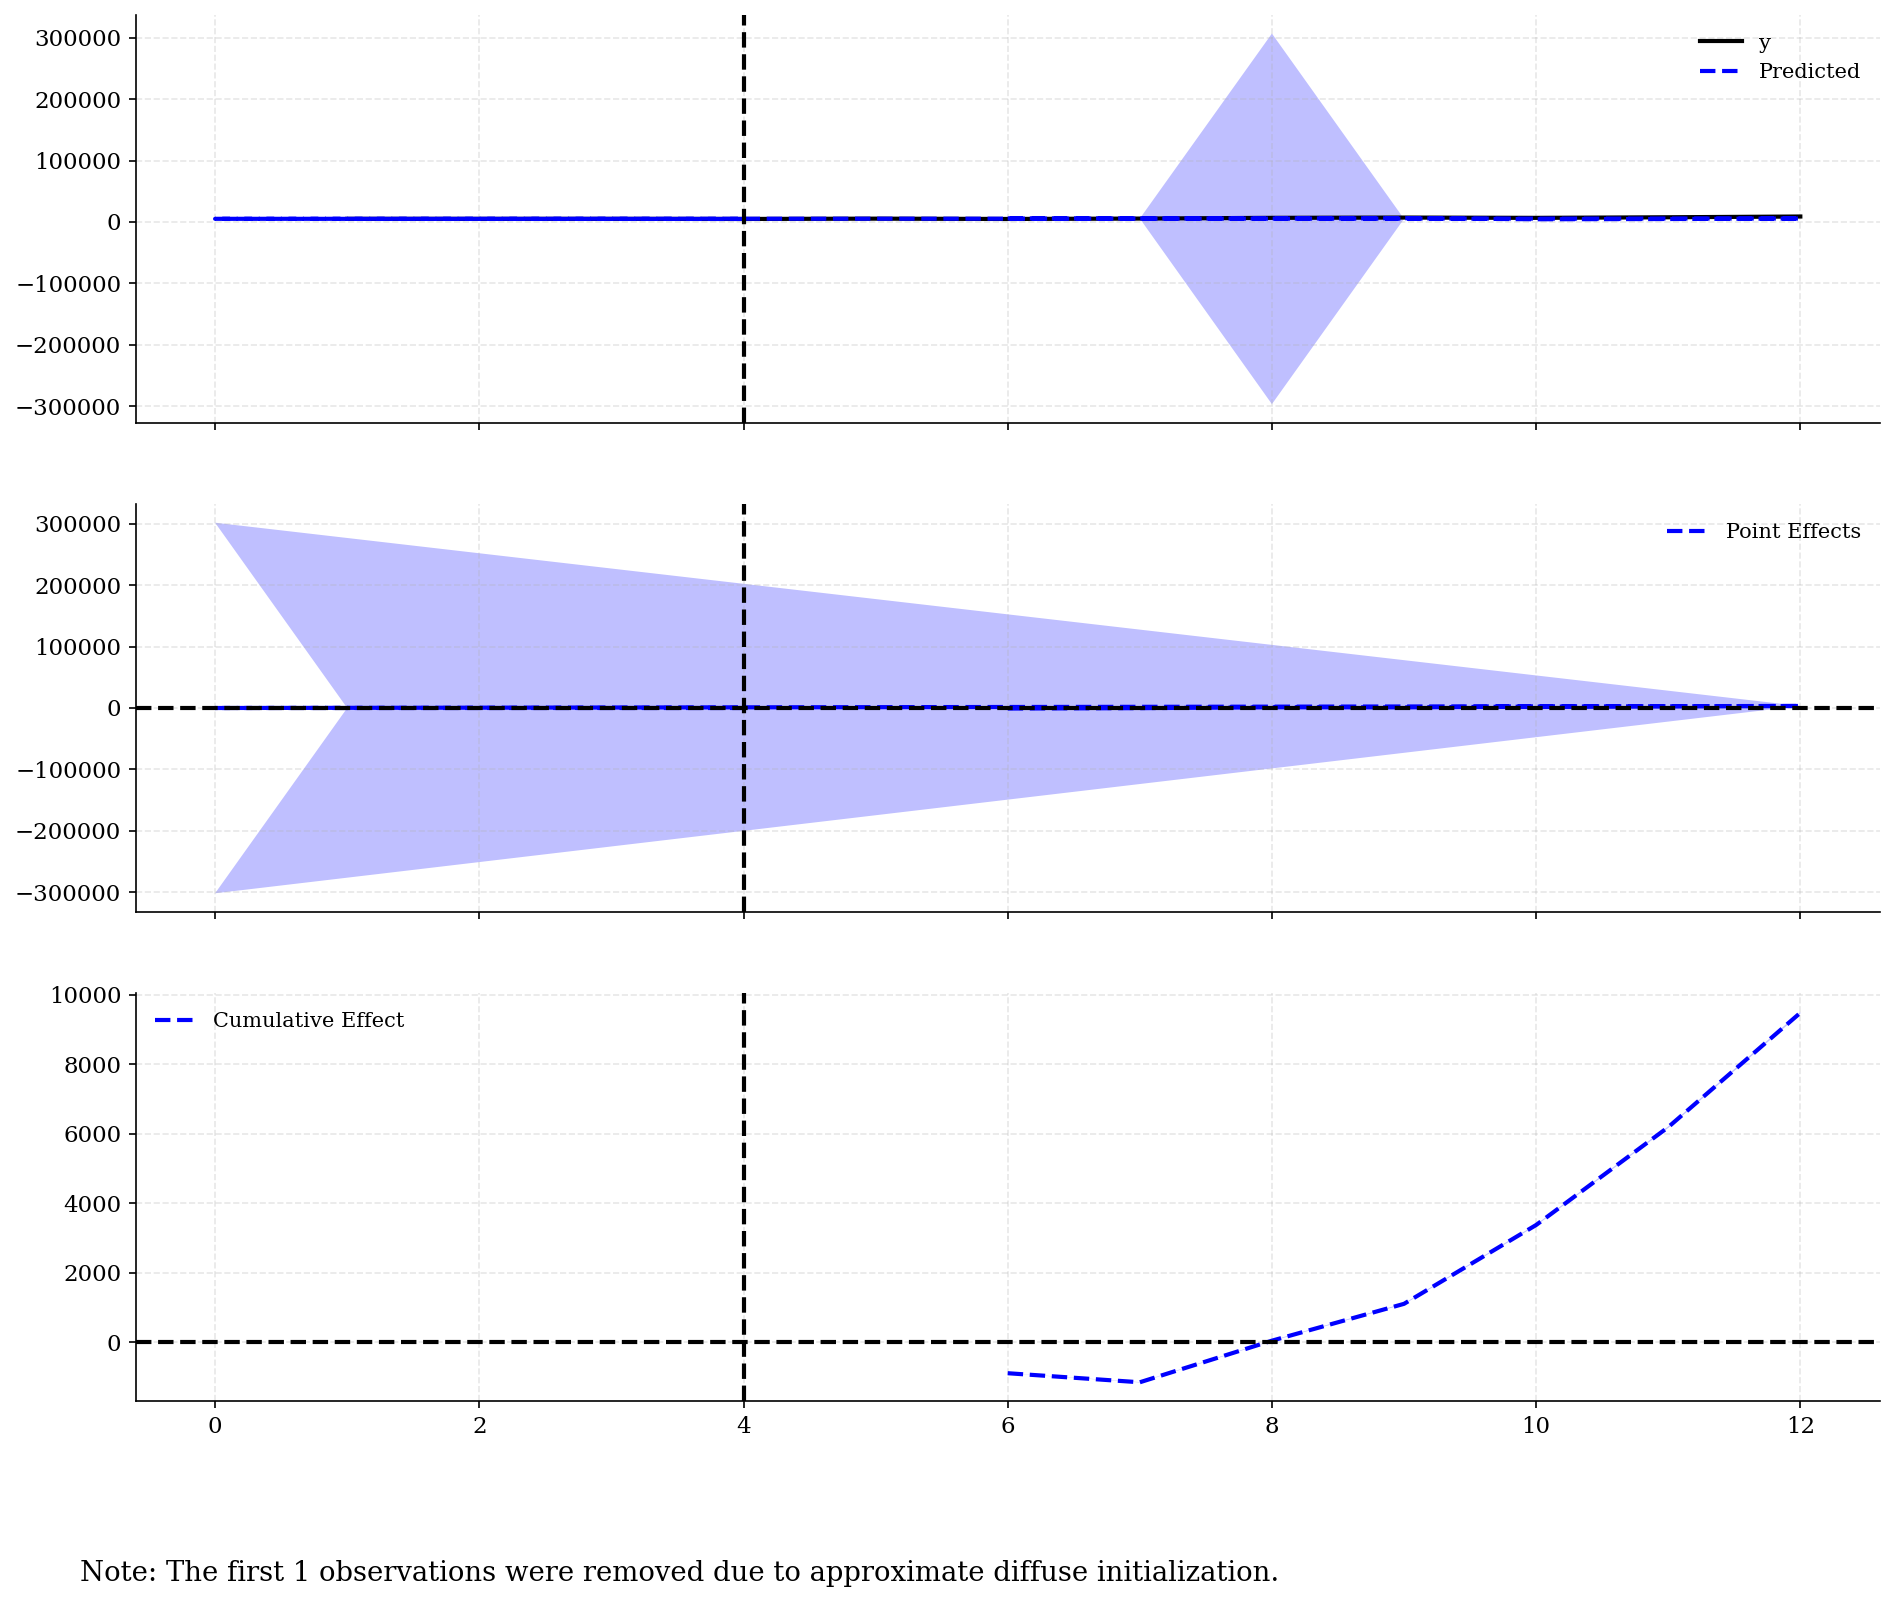

  Saved: ../results/figures/bsts_bihar_causalimpact_builtin.png


<Figure size 960x720 with 0 Axes>

In [24]:
# Use CausalImpact's built-in plot as a quick check
bsts.ci.plot()
plt.suptitle("CausalImpact — Bihar Road Accident Deaths", y=1.02)
plt.tight_layout()
save_fig(plt.gcf(), RESULTS / "bsts_bihar_causalimpact_builtin.png")
plt.show()

## 3. Custom Publication-Quality Plot

  Saved: ../results/figures/bsts_bihar_main.png


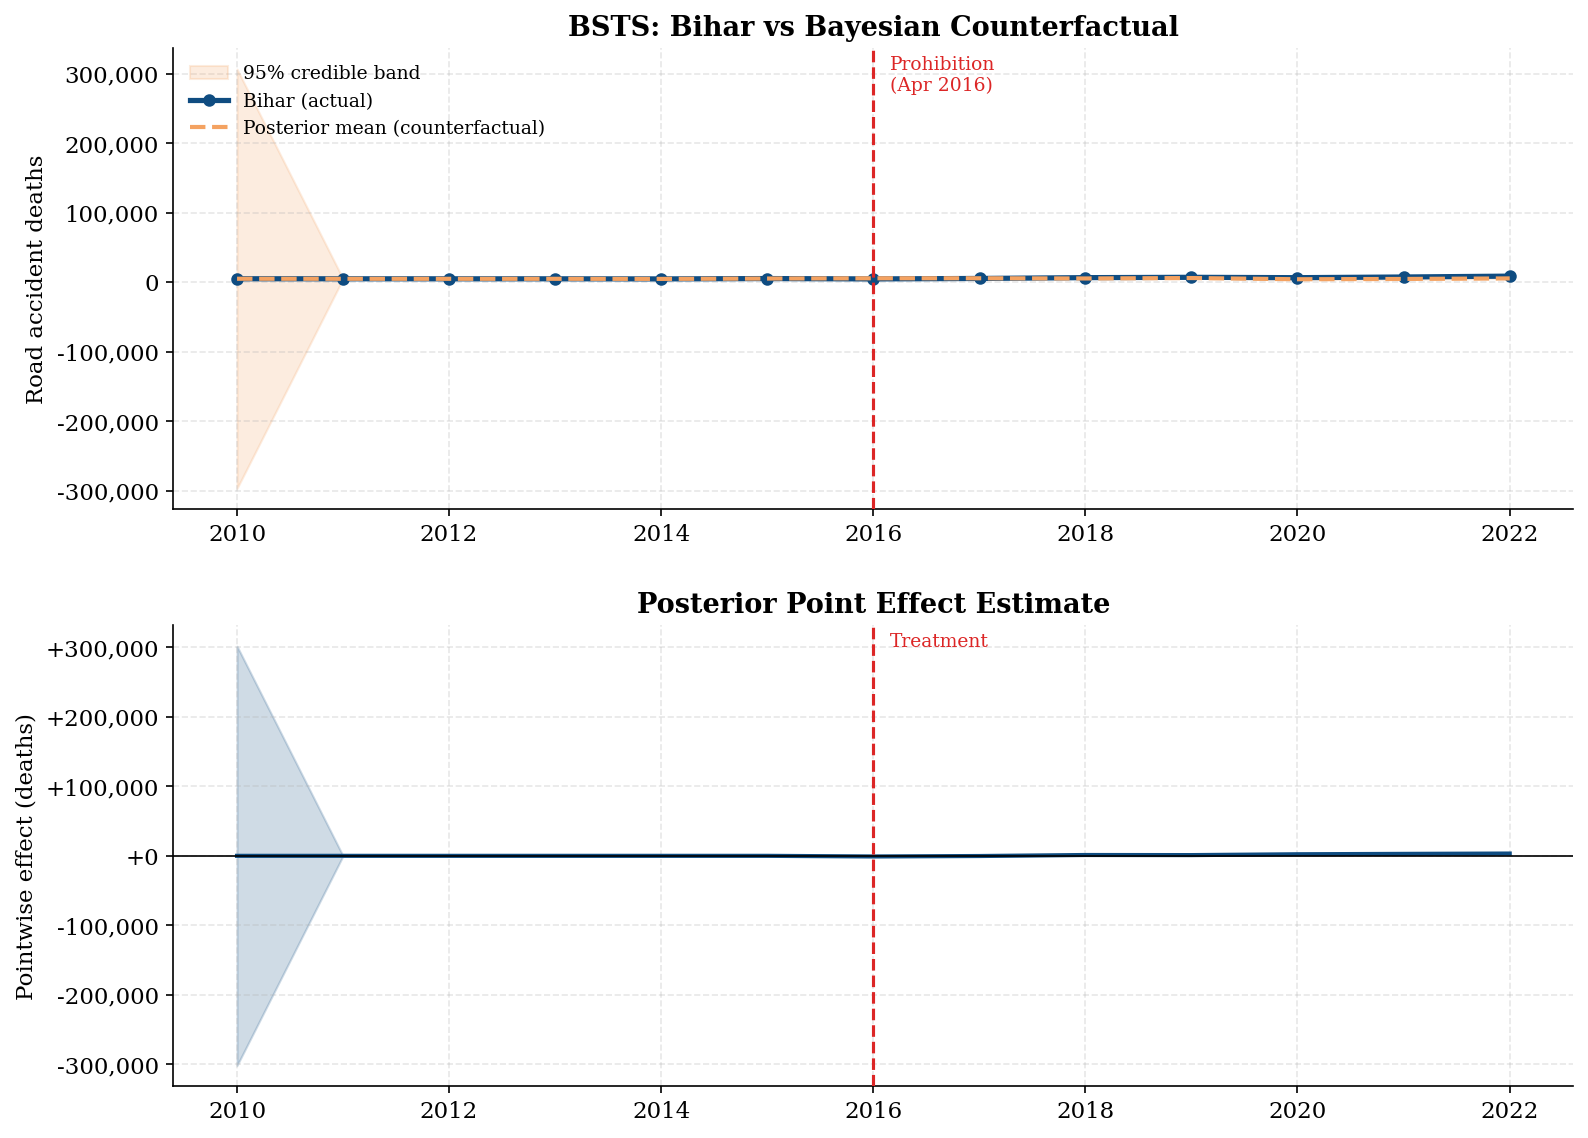

In [25]:
inf = bsts.ci.inferences.sort_index()  # pycausalimpact returns non-chronological order
observed = bsts.ci.data.iloc[:, 0]   # treated unit's observed series
dates = pd.to_datetime(bsts._dates)
treatment_dt = pd.to_datetime(TREATMENT_DATE)

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# Panel A — Observed vs Predicted (with credible band)
ax = axes[0]
pred_mean  = inf["preds"].values
pred_lower = inf["preds_lower"].values
pred_upper = inf["preds_upper"].values

ax.fill_between(dates, pred_lower, pred_upper,
                alpha=0.2, color=COLOR_SYNTHETIC, label="95% credible band")
ax.plot(dates, observed.values,
        color=COLOR_TREATED, linewidth=2.5, label="Bihar (actual)",
        marker="o", markersize=5)
ax.plot(dates, pred_mean,
        color=COLOR_SYNTHETIC, linewidth=2, linestyle="--",
        label="Posterior mean (counterfactual)")
treatment_line(ax, TREATMENT_DATE, label="Prohibition\n(Apr 2016)")
ax.set_ylabel("Road accident deaths")
ax.set_title("BSTS: Bihar vs Bayesian Counterfactual")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)

# Panel B — Pointwise effect (with credible band)
ax = axes[1]
eff       = inf["point_effects"].values
eff_lower = inf["point_effects_lower"].values
eff_upper = inf["point_effects_upper"].values

ax.fill_between(dates, eff_lower, eff_upper,
                alpha=0.2, color=COLOR_TREATED)
ax.plot(dates, eff, color=COLOR_TREATED, linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
treatment_line(ax, TREATMENT_DATE)
ax.set_ylabel("Pointwise effect (deaths)")
ax.set_title("Posterior Point Effect Estimate")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))

fig.tight_layout(pad=2)
save_fig(fig, RESULTS / "bsts_bihar_main.png")
plt.show()

## 4. Year-by-Year BSTS Estimates

In [26]:
bsts_table = pd.DataFrame({
    "Year"      : dates.year,
    "Observed"  : observed.round(0).astype("Int64").values,
    "Pred mean" : inf["preds"].round(0).astype("Int64").values,
    "Pred lower": inf["preds_lower"].round(0).astype("Int64").values,
    "Pred upper": inf["preds_upper"].round(0).astype("Int64").values,
    "Effect"    : inf["point_effects"].round(0).astype("Int64").values,
}).set_index("Year")
print(bsts_table.to_string())

      Observed  Pred mean  Pred lower  Pred upper  Effect
Year                                                     
2010      5137       5137     -296301      306575       0
2011      5090       5090        5087        5093       0
2012      5056       5056        5053        5059       0
2013      5061       5061        5058        5064       0
2014      4913       4913        4910        4916       0
2015      5421       5421        5418        5424       0
2016      4901       5800        5797        5802    -899
2017      5554       5815        5811        5818    -261
2018      6729       5531        5527        5535    1198
2019      7205       6144        6139        6149    1061
2020      6699       4428        4422        4434    2271
2021      7660       4842        4836        4848    2818
2022      8898       5605        5598        5611    3293


## 5. SCM vs BSTS Comparison

  Saved: ../results/figures/bihar_scm_vs_bsts.png


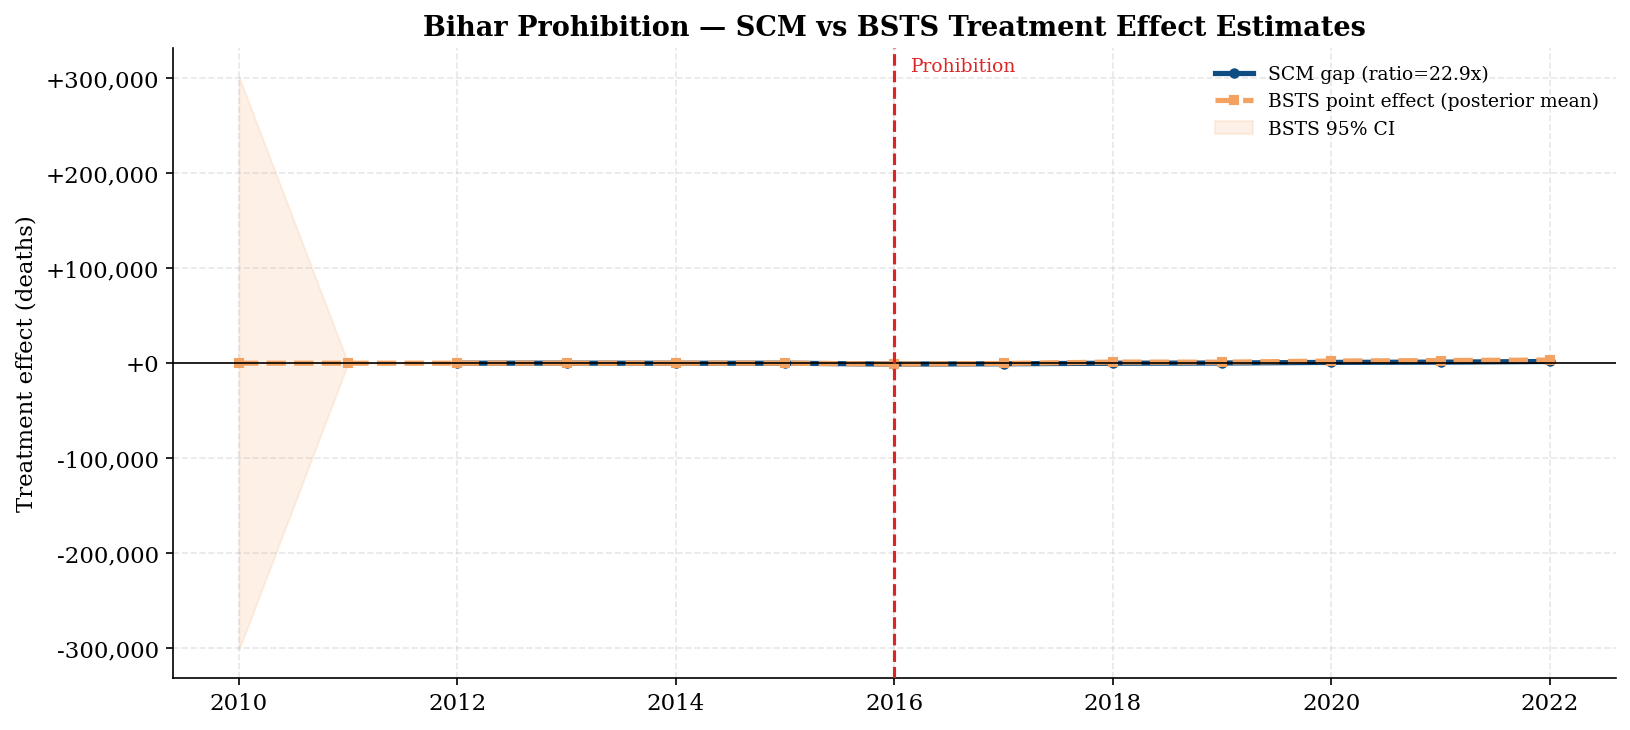

=== Post-treatment averages ===
  SCM avg gap     : +360 deaths/year
  BSTS avg effect : +1355 deaths/year
  BSTS p-value    : 0.0
  SCM RMSPE ratio : 22.87x
  SCM p-value     : ~0.071 (permutation, rank 2/14)


In [27]:
# Load SCM results
with open("../api/results/bihar_scm.json") as f:
    scm_data = json.load(f)

scm_dates = pd.to_datetime(scm_data["dates"])
scm_gap   = pd.Series(scm_data["gap"], index=scm_dates)
bsts_eff  = pd.Series(inf["point_effects"].values, index=dates)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(scm_gap.index, scm_gap,
        color=COLOR_TREATED, linewidth=2.5, linestyle="-",
        label=f"SCM gap (ratio={scm_data['diagnostics']['rmspe_ratio']:.1f}x)",
        marker="o", markersize=4)
ax.plot(bsts_eff.index, bsts_eff,
        color=COLOR_SYNTHETIC, linewidth=2.5, linestyle="--",
        label="BSTS point effect (posterior mean)",
        marker="s", markersize=4)

# BSTS credible band
ax.fill_between(dates,
                inf["point_effects_lower"].values,
                inf["point_effects_upper"].values,
                alpha=0.15, color=COLOR_SYNTHETIC, label="BSTS 95% CI")

ax.axhline(0, color="black", linewidth=0.8)
treatment_line(ax, TREATMENT_DATE, label="Prohibition")
ax.set_ylabel("Treatment effect (deaths)")
ax.set_title("Bihar Prohibition — SCM vs BSTS Treatment Effect Estimates")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, RESULTS / "bihar_scm_vs_bsts.png")
plt.show()

# Print comparison table
post_mask_scm  = scm_dates >= pd.to_datetime(TREATMENT_DATE)
post_mask_bsts = dates >= pd.to_datetime(TREATMENT_DATE)
bsts_p = getattr(bsts.ci, 'p_value', None)
print("=== Post-treatment averages ===")
print(f"  SCM avg gap     : {scm_gap[post_mask_scm].mean():+.0f} deaths/year")
print(f"  BSTS avg effect : {bsts_eff[post_mask_bsts].mean():+.0f} deaths/year")
print(f"  BSTS p-value    : {bsts_p}")
print(f"  SCM RMSPE ratio : {scm_data['diagnostics']['rmspe_ratio']:.2f}x")
print(f"  SCM p-value     : ~0.071 (permutation, rank 2/14)")

## 6. Secondary Outcome — Own Tax Revenue

In [28]:
bsts2 = BSTSAnalysis(
    panel_df       = panel,
    treated_unit   = TREATED,
    donor_pool     = DONORS,
    outcome        = OUTCOME_SECONDARY,
    treatment_date = TREATMENT_DATE,
)
bsts2.fit()
print(bsts2.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    29299.71           205098.0
Prediction (s.d.)         34167.09 (67.78)   239169.6 (474.43)
95% CI                    [34027.01, 34292.68][238189.05, 240048.76]

Absolute effect (s.d.)    -4867.37 (67.78)   -34071.6 (474.43)
95% CI                    [-4992.97, -4727.29][-34950.76, -33091.05]

Relative effect (s.d.)    -14.25% (0.2%)     -14.25% (0.2%)
95% CI                    [-14.61%, -13.84%] [-14.61%, -13.84%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


  Saved: ../results/figures/bsts_bihar_tax.png


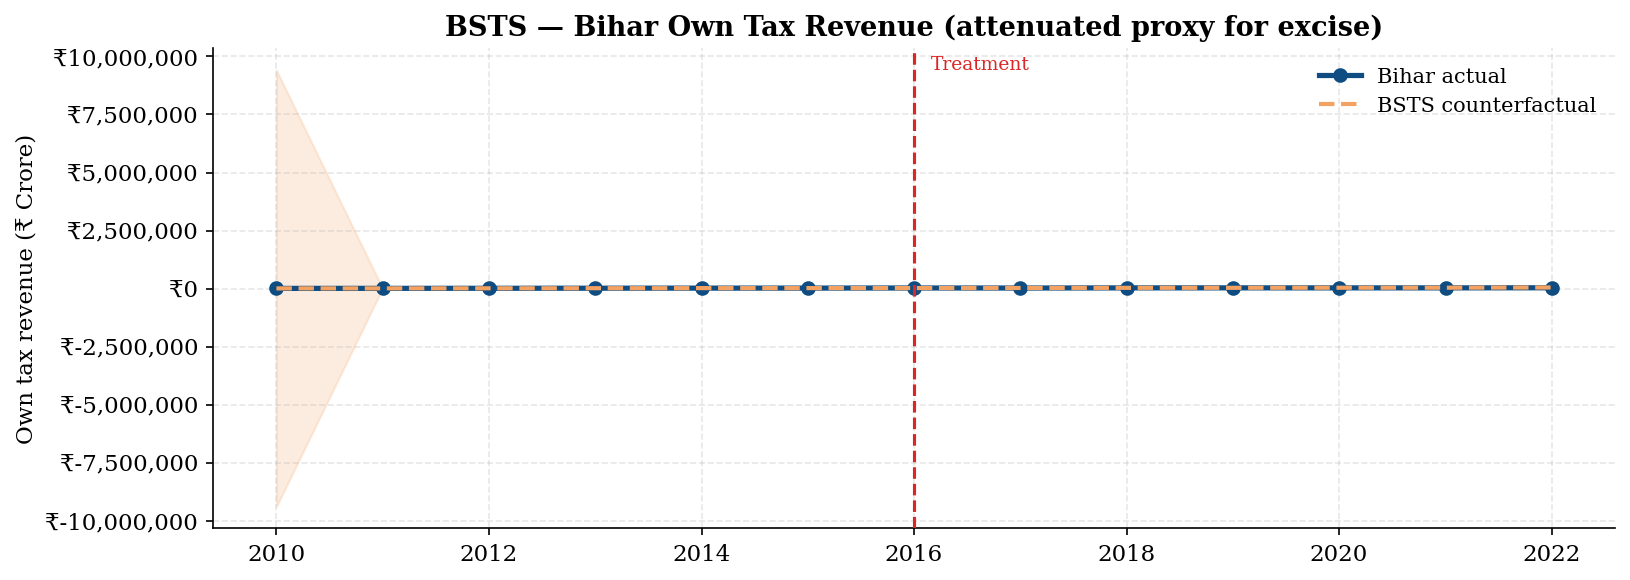

In [29]:
# Quick plot for secondary outcome
inf2     = bsts2.ci.inferences.sort_index()  # chronological
observed2= bsts2.ci.data.iloc[:, 0]
dates2   = pd.to_datetime(bsts2._dates)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(dates2, inf2["preds_lower"], inf2["preds_upper"],
                alpha=0.2, color=COLOR_SYNTHETIC)
ax.plot(dates2, observed2.values,
        color=COLOR_TREATED, linewidth=2.5, label="Bihar actual", marker="o")
ax.plot(dates2, inf2["preds"],
        color=COLOR_SYNTHETIC, linewidth=2, linestyle="--",
        label="BSTS counterfactual")
treatment_line(ax, TREATMENT_DATE)
ax.set_ylabel("Own tax revenue (₹ Crore)")
ax.set_title("BSTS — Bihar Own Tax Revenue (attenuated proxy for excise)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax.legend()
fig.tight_layout()
save_fig(fig, RESULTS / "bsts_bihar_tax.png")
plt.show()

## 7. Save Results to JSON

In [30]:
bsts.save_json("../api/results/bihar_bsts.json")
bsts2.save_json("../api/results/bihar_bsts_tax.json")

for f in ["../api/results/bihar_bsts.json", "../api/results/bihar_bsts_tax.json"]:
    size = Path(f).stat().st_size
    with open(f) as fp:
        d = json.load(fp)
    print(f"✅ {f} — {size/1024:.1f} KB")
    print(f"   p-value    : {d.get('p_value')}")
    print(f"   Post obs   : {sum(1 for i,dt in enumerate(d['dates']) if dt >= TREATMENT_DATE)}")
    post_effects = [v for v, dt in zip(d["point_effect"], d["dates"])
                    if v is not None and dt >= TREATMENT_DATE]
    if post_effects:
        print(f"   Avg effect : {np.mean(post_effects):+.0f} deaths/year")

  [BSTS] inferences columns: ['post_cum_y', 'preds', 'post_preds', 'post_preds_lower', 'post_preds_upper', 'preds_lower', 'preds_upper', 'post_cum_pred', 'post_cum_pred_lower', 'post_cum_pred_upper', 'point_effects', 'point_effects_lower', 'point_effects_upper', 'post_cum_effects', 'post_cum_effects_lower', 'post_cum_effects_upper']
  [BSTS] clipping outlier band at i=0 (2010-01-01): width=602875 vs median 7.1
  [BSTS OK] pre-period |effect| = 0.0 (0.0% of obs mean) — looks correct
  Saved JSON: ../api/results/bihar_bsts.json
  [BSTS] inferences columns: ['post_cum_y', 'preds', 'post_preds', 'post_preds_lower', 'post_preds_upper', 'preds_lower', 'preds_upper', 'post_cum_pred', 'post_cum_pred_lower', 'post_cum_pred_upper', 'point_effects', 'point_effects_lower', 'point_effects_upper', 'post_cum_effects', 'post_cum_effects_lower', 'post_cum_effects_upper']
  [BSTS] clipping outlier band at i=0 (2010-01-01): width=18799293 vs median 221.6
  [BSTS OK] pre-period |effect| = 0.0 (0.0% of obs

## 8. Summary

**BSTS findings — Road accident deaths:**
[Fill after running: paste p-value, avg effect, direction, 
and whether 95% CI excludes zero in early post-treatment years]

**Consistency with SCM:**
[Do both methods agree on direction (fewer deaths 2016-2018)?]
[Do both show the fading effect (gap reversal post-2019)?]